# Tomato Leaf Disease Detection with EfficientNetB0

This notebook trains a transfer-learning image classifier for the Kaggle tomato leaf dataset. It includes preprocessing, augmentation, EfficientNetB0 model building, callbacks, evaluation metrics, confusion matrix, training curves, class-weight handling, Grad-CAM helpers, and model saving for `app.py`.

## 1. Setup

This notebook uses the online Kaggle dataset only:

```text
https://www.kaggle.com/datasets/noulam/tomato
```

The dataset is downloaded with `kagglehub`:

```python
path = kagglehub.dataset_download("noulam/tomato")
```

If Kaggle asks for authentication, use a Kaggle token through your Kaggle/account environment. Avoid pasting secret keys directly into the notebook.

In [1]:
import os
import random
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
KAGGLE_DATASET = "noulam/tomato"
KAGGLE_DATA_ROOT = None
MODEL_PATH = PROJECT_DIR / "tomato_efficientnetb0.keras"
CLASS_NAMES_PATH = PROJECT_DIR / "class_names.npy"
MODEL_PATH_STR = str(MODEL_PATH)
CLASS_NAMES_PATH_STR = str(CLASS_NAMES_PATH)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
MIN_IMAGES_PER_CLASS = 100

print("TensorFlow:", tf.__version__)
print("Kaggle dataset:", KAGGLE_DATASET)
print("Kaggle dataset:", KAGGLE_DATASET)


TensorFlow: 2.15.0
Kaggle dataset: noulam/tomato
Kaggle dataset: noulam/tomato


In [2]:
def ensure_kagglehub():
    try:
        import kagglehub  # noqa: F401
    except Exception:
        print("Installing kagglehub package...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])


def download_from_kagglehub(dataset_slug=KAGGLE_DATASET):
    ensure_kagglehub()
    import kagglehub

    dataset_path = kagglehub.dataset_download(dataset_slug)
    dataset_path = Path(dataset_path)
    print("Path to dataset files:", dataset_path)
    return dataset_path


# Download latest online Kaggle dataset version.
KAGGLE_DATA_ROOT = download_from_kagglehub("noulam/tomato")

C:\Users\krish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\krish\.cache\kagglehub\datasets\noulam\tomato\versions\1


## 2. Load KaggleHub Data

Images are resized to 224x224. The loader searches inside the `kagglehub.dataset_download("noulam/tomato")` path for tomato `train` and `valid` folders. EfficientNetB0 receives images in the expected 0-255 scale.

In [3]:
def count_images_by_class(directory):
    if not directory.exists():
        return {}
    return {
        class_dir.name: len([p for p in class_dir.iterdir() if p.is_file()])
        for class_dir in sorted(directory.iterdir())
        if class_dir.is_dir() and class_dir.name.startswith("Tomato___")
    }


def find_kaggle_tomato_dirs(root_dir):
    candidates = []
    if root_dir.exists():
        for train_dir in root_dir.rglob("train"):
            if not train_dir.is_dir():
                continue
            train_counts = count_images_by_class(train_dir)
            if len(train_counts) < 2:
                continue
            parent = train_dir.parent
            valid_dir = parent / "valid"
            if not valid_dir.exists():
                valid_dir = parent / "Valid"
            valid_counts = count_images_by_class(valid_dir)
            if valid_counts:
                candidates.append((train_dir, valid_dir, sum(train_counts.values())))
    if not candidates:
        return None, None
    candidates.sort(key=lambda item: item[2], reverse=True)
    return candidates[0][0], candidates[0][1]


TRAIN_DIR, VALID_DIR = find_kaggle_tomato_dirs(Path(KAGGLE_DATA_ROOT))
if TRAIN_DIR is None or VALID_DIR is None:
    raise FileNotFoundError(
        "Kaggle tomato dataset folders were not found. Run the kagglehub download cell successfully first."
    )

train_counts = count_images_by_class(TRAIN_DIR)
valid_counts = count_images_by_class(VALID_DIR)
if min(train_counts.values()) < MIN_IMAGES_PER_CLASS:
    raise ValueError(
        f"Kaggle dataset looks incomplete. Minimum images in a class: {min(train_counts.values())}. "
        "Delete kaggle_tomato_dataset and rerun the Kaggle download cell."
    )

print("Using Kaggle training directory:", TRAIN_DIR)
print("Using Kaggle validation directory:", VALID_DIR)
print("Training image counts:", train_counts)
print("Validation image counts:", valid_counts)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
np.save(CLASS_NAMES_PATH_STR, np.array(class_names))

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, name)

Using Kaggle training directory: C:\Users\krish\.cache\kagglehub\datasets\noulam\tomato\versions\1\New Plant Diseases Dataset(Augmented)\train
Using Kaggle validation directory: C:\Users\krish\.cache\kagglehub\datasets\noulam\tomato\versions\1\New Plant Diseases Dataset(Augmented)\valid
Training image counts: {'Tomato___Bacterial_spot': 1702, 'Tomato___Early_blight': 1920, 'Tomato___healthy': 1926, 'Tomato___Late_blight': 1851, 'Tomato___Leaf_Mold': 1882, 'Tomato___Septoria_leaf_spot': 1745, 'Tomato___Spider_mites Two-spotted_spider_mite': 1741, 'Tomato___Target_Spot': 1827, 'Tomato___Tomato_mosaic_virus': 1790, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 1961}
Validation image counts: {'Tomato___Bacterial_spot': 425, 'Tomato___Early_blight': 480, 'Tomato___healthy': 481, 'Tomato___Late_blight': 463, 'Tomato___Leaf_Mold': 470, 'Tomato___Septoria_leaf_spot': 436, 'Tomato___Spider_mites Two-spotted_spider_mite': 435, 'Tomato___Target_Spot': 457, 'Tomato___Tomato_mosaic_virus': 448, 'Tomato

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(AUTOTUNE)

## 3. Class Weights

Class weights help if the disease folders are imbalanced.

In [5]:
train_labels = []
for class_index, class_name in enumerate(class_names):
    image_count = len(list((TRAIN_DIR / class_name).glob("*")))
    train_labels.extend([class_index] * image_count)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=np.array(train_labels),
)
class_weights = {idx: float(weight) for idx, weight in enumerate(weights)}
class_weights

{0: 1.077849588719154,
 1: 0.95546875,
 2: 0.9910858995137763,
 3: 0.9747608926673751,
 4: 1.0512893982808023,
 5: 1.053704767375072,
 6: 1.0041050903119868,
 7: 0.9354920958694544,
 8: 1.0248603351955308,
 9: 0.9524922118380063}

## 4. Build EfficientNetB0 Model

The base model uses ImageNet weights, `include_top=False`, and `input_shape=(224, 224, 3)`. Initial EfficientNet layers are frozen for transfer learning, with a custom classification head on top.

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.10),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
        tf.keras.layers.RandomBrightness(0.10, value_range=(0, 255)),
    ],
    name="data_augmentation",
)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.BatchNormalization(name="head_batch_norm")(x)
x = tf.keras.layers.Dense(512, activation="relu", name="dense_relu")(x)
x = tf.keras.layers.Dropout(0.5, name="dropout")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = tf.keras.Model(inputs, outputs, name="tomato_efficientnetb0")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()



Model: "tomato_efficientnetb0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling (Gl  (None, 1280)              0         
 obalAveragePooling2D)                                           
                                                                 
 head_batch_norm (BatchNorm  (None, 1280)              5120      
 alization)                                

## 5. Train

In [7]:
MODEL_PATH_STR = str(MODEL_PATH)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH_STR,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCH0S,
    callbacks=callbacks,
    class_weight=class_weights,
)

Epoch 1/20


574/574 [==============================] - ETA: 0s - loss: 0.5890 - accuracy: 0.8208
Epoch 1: val_accuracy improved from -inf to 0.90403, saving model to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\tomato_efficientnetb0.keras
574/574 [==============================] - 532s 864ms/step - loss: 0.5890 - accuracy: 0.8208 - val_loss: 0.2847 - val_accuracy: 0.9040 - lr: 0.0010
Epoch 2/20
574/574 [==============================] - ETA: 0s - loss: 0.3263 - accuracy: 0.8970
Epoch 2: val_accuracy improved from 0.90403 to 0.93195, saving model to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\tomato_efficientnetb0.keras
574/574 [==============================] - 454s 791ms/step - loss: 0.3263 - accuracy: 0.8970 - val_loss: 0.2152 - val_accuracy: 0.9320 - lr: 0.0010
Epoch 3/20
574/574 [==============================] - ETA: 0s - loss: 0.2707 - accuracy: 0.9136
Epoch 3: val_accuracy did not improve from 0.93195
574/574 [==============================] - 413s 72

## 6. Optional Fine-tuning

After the classification head learns, unfreeze the top EfficientNet layers with a smaller learning rate.

In [8]:
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=callbacks,
    class_weight=class_weights,
)

Epoch 1/5
574/574 [==============================] - ETA: 0s - loss: 0.0608 - accuracy: 0.9793
Epoch 1: val_accuracy improved from 0.97034 to 0.97296, saving model to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\tomato_efficientnetb0.keras
574/574 [==============================] - 588s 966ms/step - loss: 0.0608 - accuracy: 0.9793 - val_loss: 0.0924 - val_accuracy: 0.9730 - lr: 1.0000e-05
Epoch 2/5
574/574 [==============================] - ETA: 0s - loss: 0.0553 - accuracy: 0.9818
Epoch 2: val_accuracy did not improve from 0.97296
574/574 [==============================] - 476s 830ms/step - loss: 0.0553 - accuracy: 0.9818 - val_loss: 0.0947 - val_accuracy: 0.9725 - lr: 1.0000e-05
Epoch 3/5
574/574 [==============================] - ETA: 0s - loss: 0.0428 - accuracy: 0.9857
Epoch 3: val_accuracy improved from 0.97296 to 0.97623, saving model to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\tomato_efficientnetb0.keras
574/574 [==============================] - 5

## 7. Training Curves

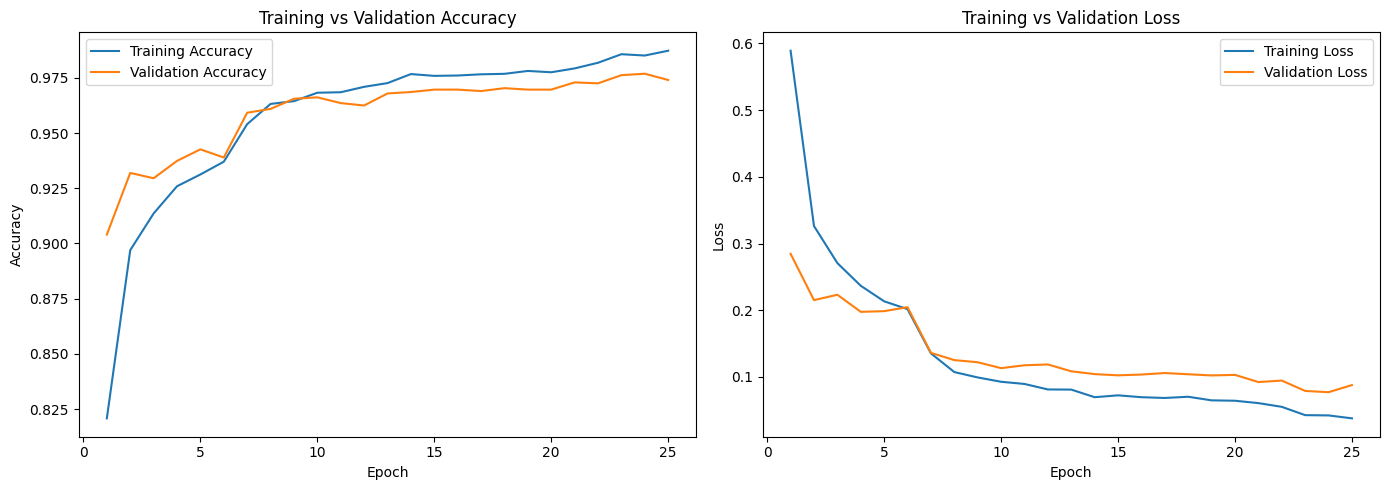

In [9]:
def plot_history(histories):
    accuracy = []
    val_accuracy = []
    loss = []
    val_loss = []

    for hist in histories:
        if hist is None:
            continue
        accuracy.extend(hist.history.get("accuracy", []))
        val_accuracy.extend(hist.history.get("val_accuracy", []))
        loss.extend(hist.history.get("loss", []))
        val_loss.extend(hist.history.get("val_loss", []))

    epochs_range = range(1, len(accuracy) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs_range, accuracy, label="Training Accuracy")
    axes[0].plot(epochs_range, val_accuracy, label="Validation Accuracy")
    axes[0].set_title("Training vs Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(epochs_range, loss, label="Training Loss")
    axes[1].plot(epochs_range, val_loss, label="Validation Loss")
    axes[1].set_title("Training vs Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history([history, locals().get("fine_tune_history")])

## 8. Evaluation

This section prints model accuracy as a percentage, shows precision/recall/F1-score, saves `model_accuracy_metrics.csv`, displays the confusion matrix, and saves both `confusion_matrix_efficientnetb0.png` and `confusion_matrix_values.csv`.

In [10]:
import pandas as pd
MODEL_PATH_STR = str(MODEL_PATH)

best_model = tf.keras.models.load_model(MODEL_PATH_STR)

y_true = []
y_pred = []

for images, labels in valid_ds:
    probabilities = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probabilities, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

model_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

metrics_summary = {
    "Accuracy": model_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
}

print("Model Evaluation Metrics")
print("-" * 32)
for metric_name, metric_value in metrics_summary.items():
    print(f"{metric_name}: {metric_value:.4f} ({metric_value * 100:.2f}%)")

metrics_df = pd.DataFrame([metrics_summary])
display(metrics_df.style.format("{:.4f}"))
metrics_df.to_csv("model_accuracy_metrics.csv", index=False)

print("Detailed Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Model Evaluation Metrics
--------------------------------
Accuracy: 0.9769 (97.69%)
Precision: 0.9775 (97.75%)
Recall: 0.9769 (97.69%)
F1-score: 0.9770 (97.70%)


,Accuracy,Precision,Recall,F1-score
0,0.9769,0.9775,0.9769,0.9770


Detailed Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.98      0.98       425
                        Tomato___Early_blight       0.99      0.94      0.97       480
                         Tomato___Late_blight       0.98      0.98      0.98       463
                           Tomato___Leaf_Mold       1.00      0.98      0.99       470
                  Tomato___Septoria_leaf_spot       0.97      0.98      0.98       436
Tomato___Spider_mites Two-spotted_spider_mite       0.97      0.96      0.97       435
                         Tomato___Target_Spot       0.90      0.96      0.93       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.99      0.99       490
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00       448
                             Tomato___healthy       0.97      0.99      0.98       481

          

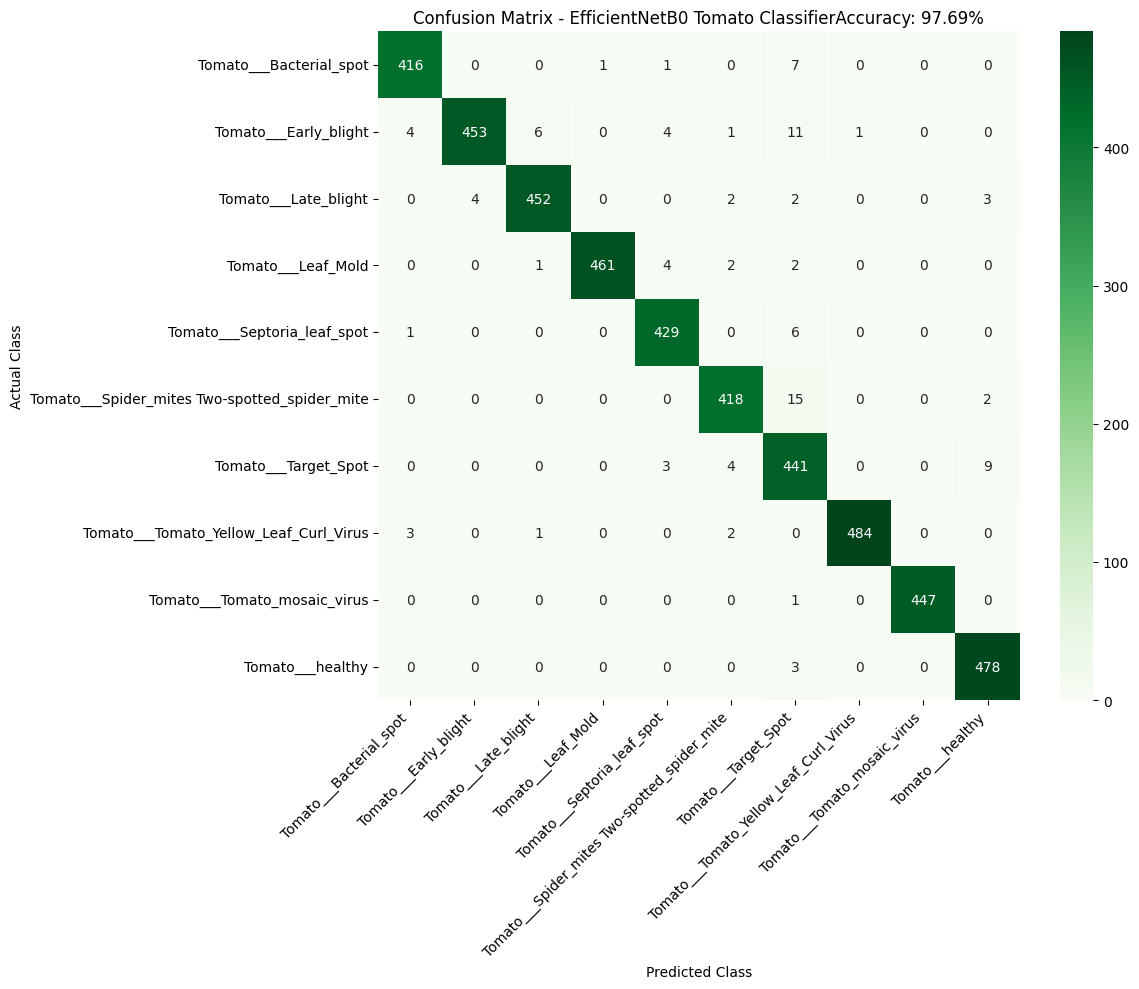

Saved confusion matrix image: confusion_matrix_efficientnetb0.png
Saved confusion matrix values: confusion_matrix_values.csv


In [11]:

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv("confusion_matrix_values.csv")

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=True)
plt.title(f"Confusion Matrix - EfficientNetB0 Tomato ClassifierAccuracy: {model_accuracy * 100:.2f}%")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_efficientnetb0.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix image: confusion_matrix_efficientnetb0.png")
print("Saved confusion matrix values: confusion_matrix_values.csv")

## 9. Inference and Validation Helpers

The Streamlit app uses the same checks: obvious non-leaf rejection, tomato-leaf sanity check, and low-confidence handling when max softmax probability is below 0.6.

In [12]:
def preprocess_image(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(image)
    array = np.expand_dims(array, axis=0) / 255.0
    return array

def predict_image(image_path, threshold=0.60):
    array = preprocess_image(image_path)
    probabilities = best_model.predict(array, verbose=0)[0]
    index = int(np.argmax(probabilities))
    confidence = float(probabilities[index])
    if confidence < threshold:
        return "Low confidence prediction. Please upload a clearer image.", confidence
    return class_names[index], confidence

## 10. Grad-CAM Bonus

In [13]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv", pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer("efficientnetb0").get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

## 11. Save Final Model

The best checkpoint is already saved as `tomato_efficientnetb0.keras`. The Streamlit app loads this file once with `st.cache_resource`.

In [14]:
MODEL_PATH_STR = str(MODEL_PATH)
CLASS_NAMES_PATH_STR = str(CLASS_NAMES_PATH)

best_model.save(MODEL_PATH_STR)
np.save(CLASS_NAMES_PATH_STR, np.array(class_names))
print("Saved model to", MODEL_PATH)
print("Saved class names to", CLASS_NAMES_PATH)

Saved model to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\tomato_efficientnetb0.keras
Saved class names to c:\Users\krish\OneDrive\Desktop\Tomato Disease Prediction\class_names.npy
